# Baseline CNN

Using device: cuda
  GPU: NVIDIA GeForce MX250
  Memory: 4.3 GB

Loaded scalograms:
  Train : (7958, 1, 64, 178)  --  1472 seizure / 6486 non-seizure
  Val   : (1702, 1, 64, 178)  --  414 seizure / 1288 non-seizure
  Test  : (1725, 1, 64, 178)  --  391 seizure / 1334 non-seizure

Calculated pos_weight: 4.41  (6486 non-seizure / 1472 seizure)

RANDOM SEARCH  (optimising for Recall)
Max trials : 20  |  Patience : 7  |  Min delta : 0.01

Parameter space:
  lr: [0.0001, 0.001, 0.01]
  batch_size: [32, 64, 128]
  dropout: [0.3, 0.5, 0.7]
  pos_weight: [3.3046875, 4.40625, 5.5078125]

Trial 01/20 | Config: {'lr': 0.001, 'batch_size': 128, 'dropout': 0.3, 'pos_weight': 3.3046875}
  -> New best: 0.9976  (improved by 0.9976)

Trial 02/20 | Config: {'lr': 0.001, 'batch_size': 128, 'dropout': 0.7, 'pos_weight': 3.3046875}
  -> Recall: 0.9976  (improvement +0.0000 < 0.01 — no_improve: 1/7)

Trial 03/20 | Config: {'lr': 0.0001, 'batch_size': 128, 'dropout': 0.5, 'pos_weight': 4.40625}
  -> Recall: 

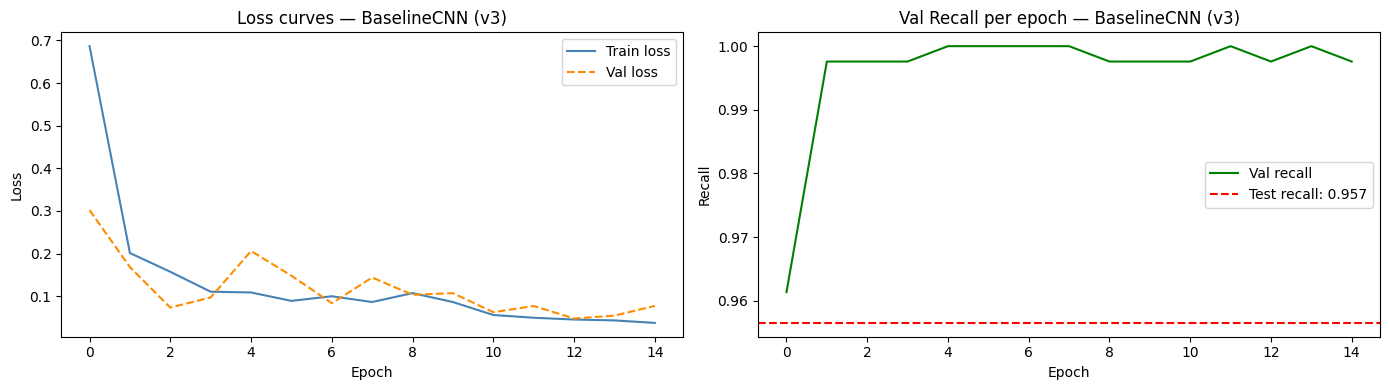

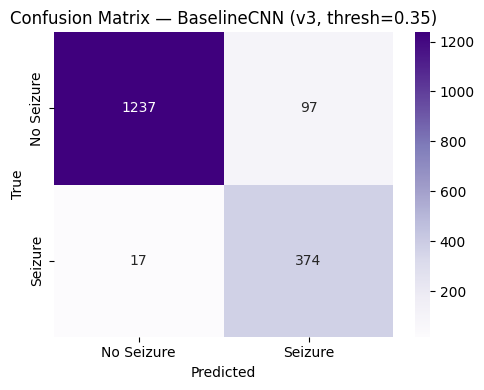

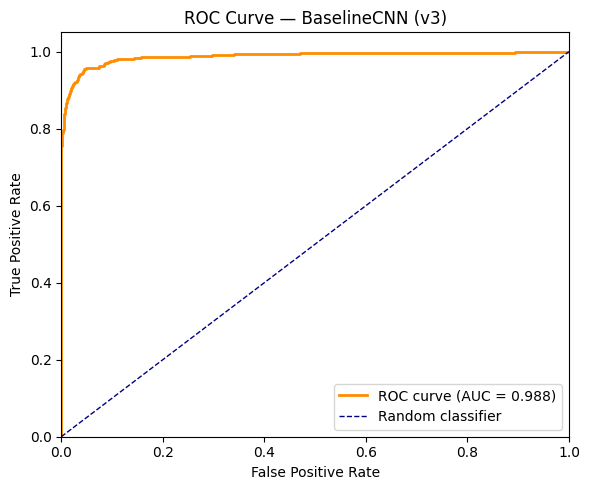

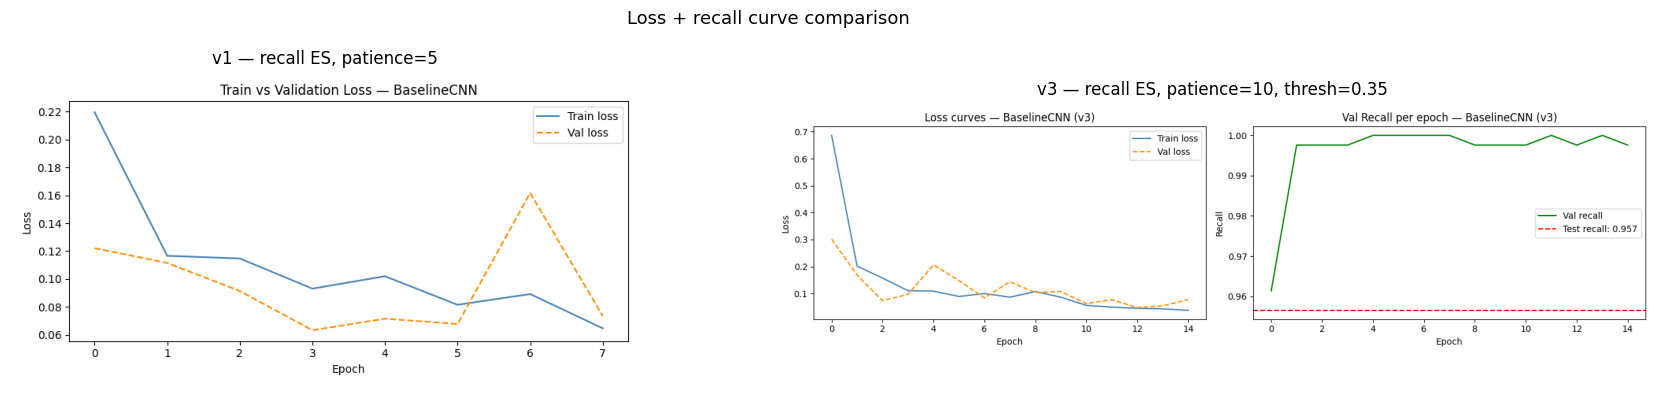

: 

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, confusion_matrix,
                             roc_curve, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — DEVICE
# ─────────────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — LOAD SCALOGRAMS
# ─────────────────────────────────────────────────────────────────────────────

X_train = np.load("scalograms/X_train.npy")
y_train = np.load("scalograms/y_train.npy")
X_val   = np.load("scalograms/X_val.npy")
y_val   = np.load("scalograms/y_val.npy")
X_test  = np.load("scalograms/X_test.npy")
y_test  = np.load("scalograms/y_test.npy")

print(f"\nLoaded scalograms:")
print(f"  Train : {X_train.shape}  --  {int(y_train.sum())} seizure / {int((y_train==0).sum())} non-seizure")
print(f"  Val   : {X_val.shape}  --  {int(y_val.sum())} seizure / {int((y_val==0).sum())} non-seizure")
print(f"  Test  : {X_test.shape}  --  {int(y_test.sum())} seizure / {int((y_test==0).sum())} non-seizure")

n_neg      = int((y_train == 0).sum())
n_pos      = int(y_train.sum())
POS_WEIGHT = n_neg / n_pos
print(f"\nCalculated pos_weight: {POS_WEIGHT:.2f}  ({n_neg} non-seizure / {n_pos} seizure)")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — DATASET
# ─────────────────────────────────────────────────────────────────────────────

class ScalogramDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — MODEL
# ─────────────────────────────────────────────────────────────────────────────

class BaselineCNN(nn.Module):
    def __init__(self, dropout):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 22, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — TRAINING FUNCTION (used during random search)
# ─────────────────────────────────────────────────────────────────────────────

def train_one_config(config, X_train, y_train, X_val, y_val, epochs=15):

    train_loader = DataLoader(
        ScalogramDataset(X_train, y_train),
        batch_size=config["batch_size"], shuffle=True
    )
    val_loader = DataLoader(
        ScalogramDataset(X_val, y_val),
        batch_size=config["batch_size"], shuffle=False
    )

    model     = BaselineCNN(dropout=config["dropout"]).to(device)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([config["pos_weight"]]).to(device)
    )
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_recall  = 0.0
    best_weights = None

    for epoch in range(epochs):

        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_X).squeeze(-1), batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        preds_all, true_all = [], []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                probs = torch.sigmoid(model(batch_X).squeeze(-1)).cpu().numpy()
                preds_all.extend((probs > 0.5).astype(int))
                true_all.extend(batch_y.cpu().numpy().astype(int))

        val_recall = recall_score(true_all, preds_all, zero_division=0)
        if val_recall > best_recall:
            best_recall  = val_recall
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        scheduler.step(val_recall)

    return best_recall, best_weights


# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — RANDOM SEARCH
# ─────────────────────────────────────────────────────────────────────────────

PARAM_SPACE = {
    "lr":         [0.0001, 0.001, 0.01],
    "batch_size": [32, 64, 128],
    "dropout":    [0.3, 0.5, 0.7],
    "pos_weight": [POS_WEIGHT * 0.75, POS_WEIGHT, POS_WEIGHT * 1.25],
}

N_TRIALS      = 20
SEARCH_EPOCHS = 15
PATIENCE      = 7
MIN_DELTA     = 0.01

print("\n" + "="*60)
print("RANDOM SEARCH  (optimising for Recall)")
print("="*60)
print(f"Max trials : {N_TRIALS}  |  Patience : {PATIENCE}  |  Min delta : {MIN_DELTA}")
print(f"\nParameter space:")
for k, v in PARAM_SPACE.items():
    print(f"  {k}: {v}")
print()

results            = []
best_recall_so_far = 0.0
no_improve_count   = 0

for trial in range(N_TRIALS):
    config     = {k: random.choice(v) for k, v in PARAM_SPACE.items()}
    print(f"Trial {trial+1:02d}/{N_TRIALS} | Config: {config}")
    val_recall, best_weights = train_one_config(
        config, X_train, y_train, X_val, y_val, epochs=SEARCH_EPOCHS
    )
    results.append((val_recall, config, best_weights))
    improvement = val_recall - best_recall_so_far
    if improvement >= MIN_DELTA:
        best_recall_so_far = val_recall
        no_improve_count   = 0
        print(f"  -> New best: {val_recall:.4f}  (improved by {improvement:.4f})\n")
    else:
        no_improve_count += 1
        print(f"  -> Recall: {val_recall:.4f}  "
              f"(improvement {improvement:+.4f} < {MIN_DELTA} "
              f"— no_improve: {no_improve_count}/{PATIENCE})\n")
    if no_improve_count >= PATIENCE:
        print(f"Early stopping — no meaningful improvement for {PATIENCE} trials.\n")
        break

results.sort(key=lambda x: x[0], reverse=True)
print("="*60)
print("TOP 5 CONFIGURATIONS:")
print("="*60)
for i, (recall, config, _) in enumerate(results[:5]):
    print(f"  #{i+1}  Recall: {recall:.4f}  |  {config}")

best_recall_search, best_config, _ = results[0]
print(f"\nBest config : {best_config}")
print(f"Best Recall : {best_recall_search:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 — RETRAIN BEST CONFIG
# ─────────────────────────────────────────────────────────────────────────────

FINAL_EPOCHS      = 30
RETRAIN_PATIENCE  = 10    # epochs without recall improvement before stopping
RETRAIN_MIN_DELTA = 0.002  # minimum recall gain to count as real progress
THRESHOLD         = 0.35   # classification threshold (lower = higher recall)

print("\n" + "="*60)
print(f"RETRAINING BEST CONFIG FOR UP TO {FINAL_EPOCHS} EPOCHS")
print(f"Early stopping : recall-based  |  patience={RETRAIN_PATIENCE}  |  delta={RETRAIN_MIN_DELTA}")
print(f"Scheduler      : val_loss-based  |  patience=6")
print(f"Threshold      : {THRESHOLD}")
print("="*60)

train_loader = DataLoader(
    ScalogramDataset(X_train, y_train),
    batch_size=best_config["batch_size"], shuffle=True
)
val_loader = DataLoader(
    ScalogramDataset(X_val, y_val),
    batch_size=best_config["batch_size"], shuffle=False
)
test_loader = DataLoader(
    ScalogramDataset(X_test, y_test),
    batch_size=best_config["batch_size"], shuffle=False
)

model     = BaselineCNN(dropout=best_config["dropout"]).to(device)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([best_config["pos_weight"]]).to(device)
)
optimizer = optim.Adam(model.parameters(), lr=best_config["lr"])

# Scheduler watches val_loss — smooth signal for LR adjustment
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=6
)

best_recall          = 0.0
best_recall_patience = 0.0   # separate tracker for patience
best_weights         = None
no_improve_retrain   = 0
history              = {"train_loss": [], "val_loss": [], "val_recall": [], "lr": []}

for epoch in range(FINAL_EPOCHS):

    current_lr = optimizer.param_groups[0]["lr"]

    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_X).squeeze(-1), batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss, preds_all, true_all = 0.0, [], []
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            out      = model(batch_X).squeeze(-1)
            val_loss += criterion(out, batch_y).item()
            probs     = torch.sigmoid(out).cpu().numpy()
            preds_all.extend((probs > THRESHOLD).astype(int))
            true_all.extend(batch_y.cpu().numpy().astype(int))

    avg_train  = train_loss / len(train_loader)
    avg_val    = val_loss   / len(val_loader)
    val_recall = recall_score(true_all, preds_all, zero_division=0)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_recall"].append(val_recall)
    history["lr"].append(current_lr)

    scheduler.step(avg_val)
    new_lr = optimizer.param_groups[0]["lr"]

    lr_note = f"  [LR reduced: {current_lr:.6f} → {new_lr:.6f}]" if new_lr < current_lr else ""
    print(f"Epoch {epoch+1:02d}/{FINAL_EPOCHS} | "
          f"Train loss: {avg_train:.4f} | "
          f"Val loss: {avg_val:.4f} | "
          f"Val recall: {val_recall:.4f}{lr_note}")

    # Save best weights by recall (any improvement)
    if val_recall > best_recall:
        best_recall  = val_recall
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  -> Best recall updated: {best_recall:.4f}")

    # Early stopping tracks recall
    if val_recall >= best_recall_patience + RETRAIN_MIN_DELTA:
        best_recall_patience = val_recall
        no_improve_retrain   = 0
    else:
        no_improve_retrain += 1

    if no_improve_retrain >= RETRAIN_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} — "
              f"recall did not improve for {RETRAIN_PATIENCE} consecutive epochs.")
        break

model.load_state_dict(best_weights)
print(f"\nRetraining complete. Best val recall: {best_recall:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 8 — TRAINING REPORT
# ─────────────────────────────────────────────────────────────────────────────

epochs_ran   = len(history["train_loss"])
best_ep      = history["val_recall"].index(max(history["val_recall"])) + 1
lr_cuts      = sum(1 for i in range(1, len(history["lr"])) if history["lr"][i] < history["lr"][i-1])
recall_vals  = history["val_recall"]

print("\n" + "="*60)
print("TRAINING REPORT")
print("="*60)
print(f"  Epochs ran          : {epochs_ran} / {FINAL_EPOCHS}")
print(f"  Best val recall     : {max(recall_vals):.4f}  at epoch {best_ep}")
print(f"  Final val recall    : {recall_vals[-1]:.4f}")
print(f"  Val recall range    : {min(recall_vals):.4f} – {max(recall_vals):.4f}")
print(f"  LR reductions       : {lr_cuts}  (final LR: {history['lr'][-1]:.6f})")
print(f"  Train loss (final)  : {history['train_loss'][-1]:.4f}")
print(f"  Val loss   (final)  : {history['val_loss'][-1]:.4f}")

gap = history["train_loss"][-1] - history["val_loss"][-1]
if gap > 0.05:
    print(f"  Overfitting signal  : train loss > val loss by {gap:.4f} — model may be overfitting")
elif history["val_loss"][-1] > history["train_loss"][-1] + 0.05:
    print(f"  Underfitting signal : val loss > train loss by {abs(gap):.4f}")
else:
    print(f"  Loss gap            : {abs(gap):.4f}  (train ≈ val — good generalisation)")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 9 — TEST EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

model.eval()
probs_all, true_all = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        probs   = torch.sigmoid(model(batch_X).squeeze(-1)).cpu().numpy()
        probs_all.extend(probs.tolist())
        true_all.extend(batch_y.numpy().astype(int).tolist())

probs_arr = np.array(probs_all)
preds_arr = (probs_arr > THRESHOLD).astype(int)

precision = precision_score(true_all, preds_arr, zero_division=0)
recall    = recall_score(true_all,    preds_arr, zero_division=0)
f1        = f1_score(true_all,        preds_arr, zero_division=0)
roc_auc   = roc_auc_score(true_all,   probs_arr)
cm        = confusion_matrix(true_all, preds_arr)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("\n" + "="*60)
print(f"TEST EVALUATION  (threshold = {THRESHOLD})")
print("="*60)
print(f"  Precision   : {precision:.3f}  — of predicted seizures, how many were real")
print(f"  Recall      : {recall:.3f}  — of real seizures, how many did we catch")
print(f"  Specificity : {specificity:.3f}  — of real non-seizures, how many correctly rejected")
print(f"  F1-score    : {f1:.3f}  — harmonic mean of precision and recall")
print(f"  ROC-AUC     : {roc_auc:.3f}  — threshold-independent ranking ability")
print(f"\n  Confusion matrix:")
print(f"    TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"    Missed seizures (FN) : {fn}  out of {tp+fn} total")
print(f"    False alarms   (FP) : {fp}  out of {tn+fp} total")

# ── Threshold sweep — shows the recall/precision tradeoff at different cutoffs ──
print(f"\n  Threshold sweep:")
print(f"  {'Thresh':>7} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Specificity':>12} {'FN':>5} {'FP':>5}")
for t in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    p_t   = (probs_arr > t).astype(int)
    r_t   = recall_score(true_all, p_t, zero_division=0)
    pr_t  = precision_score(true_all, p_t, zero_division=0)
    f1_t  = f1_score(true_all, p_t, zero_division=0)
    cm_t  = confusion_matrix(true_all, p_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    sp_t  = tn_t / (tn_t + fp_t)
    mark  = "  <--" if t == THRESHOLD else ""
    print(f"  {t:>7.2f} {r_t:>8.4f} {pr_t:>10.4f} {f1_t:>8.4f} {sp_t:>12.4f} {fn_t:>5} {fp_t:>5}{mark}")

# Val recall vs test recall gap
val_recall_at_best = max(history["val_recall"])
print(f"\n  Val→Test recall gap : {val_recall_at_best:.4f} → {recall:.4f}  "
      f"({val_recall_at_best - recall:+.4f})")
if val_recall_at_best - recall > 0.05:
    print("  Warning: large gap — model may be overfitting to the validation set")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 10 — PLOTS  (v3)
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs("plots", exist_ok=True)

# ── Plot 1: Train vs Val loss ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history["train_loss"], label="Train loss", color="steelblue")
axes[0].plot(history["val_loss"],   label="Val loss",   color="darkorange", linestyle="--")
axes[0].set_title("Loss curves — BaselineCNN (v3)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history["val_recall"], label="Val recall", color="green")
axes[1].axhline(recall, color="red", linestyle="--", label=f"Test recall: {recall:.3f}")
axes[1].set_title("Val Recall per epoch — BaselineCNN (v3)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Recall"); axes[1].legend()

plt.tight_layout()
plt.savefig("plots/baseline_loss_curves_v3.png", dpi=100)
plt.show()

# ── Plot 2: Confusion matrix ──
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Seizure", "Seizure"],
            yticklabels=["No Seizure", "Seizure"])
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Confusion Matrix — BaselineCNN (v3, thresh={THRESHOLD})")
plt.tight_layout()
plt.savefig("plots/baseline_confusion_matrix_v3.png", dpi=100)
plt.show()

# ── Plot 3: ROC curve ──
fpr, tpr, _ = roc_curve(true_all, probs_arr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random classifier")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — BaselineCNN (v3)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("plots/baseline_roc_curve_v3.png", dpi=100)
plt.show()

# ── Plot 4: v1 vs v3 loss comparison ──
v1_path = "plots/baseline_loss_curves_v1.png"
v3_path = "plots/baseline_loss_curves_v3.png"
if os.path.exists(v1_path):
    img_v1 = plt.imread(v1_path)
    img_v3 = plt.imread(v3_path)
    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    axes[0].imshow(img_v1); axes[0].axis("off"); axes[0].set_title("v1 — recall ES, patience=5")
    axes[1].imshow(img_v3); axes[1].axis("off"); axes[1].set_title("v3 — recall ES, patience=10, thresh=0.35")
    plt.suptitle("Loss + recall curve comparison", fontsize=13)
    plt.tight_layout()
    plt.savefig("plots/baseline_loss_comparison_v3.png", dpi=100)
    plt.show()